In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
plt.rcParams.update({'figure.dpi':100,'font.size':15})

In [3]:
def phi_spec(kappa, s = 4, kappa_peak = 1):
    kappa = np.asarray(kappa,dtype=float)
    C_prime = kappa_peak ** (s + 5/3)
    out = np.where(kappa <kappa_peak, kappa ** s, C_prime * kappa ** (-5/3))
    return out

def xi_t(t, q, t1 =1):
    return (1 + t/t1) ** q

def E_spec(k, t, beta ,q_exp, k0_init=1, t1=1, s=4):
    xi = xi_t(t,q_exp,t1)
    kappa = k * xi / k0_init
    return  xi ** (-beta) * phi_spec(kappa, s=s, kappa_peak=1.0)

def k_peak_t(t, k0_init,q_exp, t1=1):
    return k0_init / xi_t(t, q_exp, t1)

def E_at_peak(t,k0_init,beta,q_exp, t1=1,s=4):
    kp = k_peak_t(t,k0_init,q_exp,t1)
    return E_spec(kp, t, beta, q_exp, k0_init,t1,s)


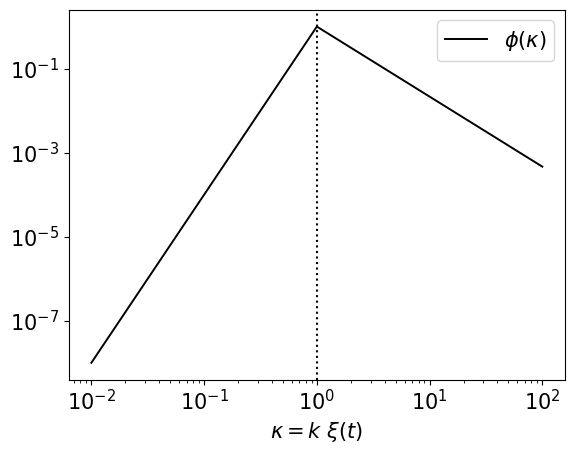

In [4]:
kappa_test = np.logspace(-2,2,1000)
phi_test = phi_spec(kappa_test,s=4, kappa_peak=1.0)



plt.loglog(kappa_test,phi_test,lw =1.4,c="black", label=r"$\phi(\kappa)$")
plt.axvline(1.0,ymin=0, ymax=1, ls=":", c="black")

plt.xlabel(r"$\kappa = k ~ \xi(t)$")
plt.legend()
plt.show()

In [18]:
CLASSES = {
    'HD  β=4  (Loitsiansky)':  dict(beta=4, q=2/7,  p=10/7, color='steelblue',  ls='-'),
    'HD  β=3  (Saffman)':      dict(beta=3, q=1/3,  p=4/3,  color='royalblue',  ls='--'),
    'nonhelical MHD  β=1':     dict(beta=1, q=1/2,  p=1.0,  color='darkorange', ls='-'),
    'helical MHD  β=0':        dict(beta=0, q=2/3,  p=2/3,  color='crimson',    ls='-'),
}

kappa_peak = 0.6
kinit_peak = 1  
t1 = 1

k_grid = np.logspace(-3,3,2000)
T_MAX = 40
N_TRIALS = 200

_fig_explorer = None

def _plot_sperctra(dec_class, log_t_over_t1,log_k0):
    global _fig_explorer
    t = 100 ** log_t_over_t1
    k0 = 10 ** log_k0
    cls = CLASSES[dec_class]
    beta, q_exp, c = cls["beta"], cls["q"], cls["color"]
    norm = Normalize(vmin=0, vmax=T_MAX)
    cmap = cm.plasma

    if _fig_explorer is None  or not plt.fignum_exists(_fig_explorer.number):
        _fig_explorer, axes = plt.subplots(1,2,figsize=(16,8))
        _fig_explorer.canvas.header_visible = False
    else:
        _fig_explorer.clf()
        axes = _fig_explorer.subplorts(1,2)

    ax1, ax2 = axes 

    t_snapshots = np.logspace(-2,np.log10(max(t, 0.011)),4)
    for t_snap in t_snapshots:
        ax1.loglog(k_grid,E_spec(k_grid, t_snap,
                                beta, q_exp,
                                k0, s=4),
                                "-", c=c,lw=0.8,
                                zorder = 1)
    ax1.loglog(k_grid,E_spec(k_grid,t,beta,q_exp,k0,s=4),"-.",
               c=c,
               lw=1.2,zorder=3)
    

from ipywidgets import interact, FloatLogSlider, FloatSlider, Dropdown, fixed

interact(
    _plot_sperctra,
    dec_class = Dropdown(options=list(CLASSES.keys()),
                         description = "CLASS"),
    log_t_over_t1=FloatSlider(value=-1.0, min=-2.0, max=np.log10(T_MAX),
                               step=0.05, description=r'log₁₀(t/t₁):',
                               style={'description_width': '120px'}),

                  
    log_k0=FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.25,
                       description='log₁₀(k₀):',
                       style={'description_width': '120px'}),
                       
)

interactive(children=(Dropdown(description='CLASS', options=('HD  β=4  (Loitsiansky)', 'HD  β=3  (Saffman)', '…

<function __main__._plot_sperctra(dec_class, log_t_over_t1, log_k0)>